# Would you like this boba?

### Logistic regression, decision boundaries, and cross-validation

**Machine Learning Principles · 01:198:461 · Recitation 1**  
September 15, 2026

## One drink, three different preferences

Our fictional menu has two inputs and one recorded response:

| Symbol | Meaning | Values |
|---|---|---|
| $x_1$ | Sugar setting | $0\%$–$300\%$ |
| $x_2$ | Ice setting | $0\%$–$100\%$ |
| $y$ | Preference label | $1$: Like; $0$: Don't like |

$100\%$ sugar is the shop's reference amount; $300\%$ is three times that amount.
Ice ranges from no ice to the reference full-ice setting. Tea, milk, toppings and all
other choices stay fixed. These are **simulated recipes and ratings**, not survey data.

- **Avery** motivates a straight decision boundary.
- **Blake** motivates squared features and a curved boundary.
- **Chris** motivates an interaction between sugar and ice.

We fit a separate model for each student. Our goals are to understand which features a
model can use, what regularization changes, and how to compare hyperparameter
configurations without using the final test data.

### Model and supporting code

The next cell embeds `LogisticRegressor` from the **released HW1 `test_solution.py`**, with
its feature convention and RMSProp-plus-shrinkage update. It also contains this notebook's
synthetic boba generator and plotting functions. No helper files are needed.

Necessary corrections provide numerically stable sigmoid probabilities, both terms of
binary cross-entropy, and consistent whole-training-set diagnostics. They do not replace
the instructor's weight update. The class now supports both `l1` and `l2`.

| Operation | Call | Input layout / result |
|---|---|---|
| Construct a fresh model | `LogisticRegressor(...)` | Choose its configuration explicitly |
| Train | `model.fit(X.T, y)` | Features by samples |
| Predict probabilities | `model.decision_function(X)` | Samples by features; returns $P(y=1\mid x)$ |
| Predict classes | `model.predict(X)` | Samples by features; returns $0$ or $1$ |

The released class's `decision_function` returns probabilities, not raw scores.
Pay attention to the different input layouts for training and prediction. Also distinguish
the coordinate named `y` from the class label $y$.


Reference: [Multivariate and Vector Orientations](https://firner.com/presentations/cs461/2026-Fall/cs461_04/#/44). [Released HW1 source](https://firner.com/presentations/cs461/2026-Fall/hw1/test_solution.py).

In [2]:
#@title Supporting code: released instructor model and boba examples
"""Boba examples using a minimally corrected copy of the professor's solver.

The optimization and interface follow the released HW1 test_solution.py:
* fit receives X in [feature, sample] order; decision_function receives
  [sample, feature] and RETURNS P(class=1), not logits.
* Raw inputs are standardized BEFORE feature expansion, using training-only
  mean and std + 10e-5. No post-expansion standardization is added.
* Features are [a**k,b**k] for k=1..degree, with (ab)**k inserted at each k
  if cross_features=True. This is not a complete total-degree polynomial map.
* Weight updates use RMSProp (beta=.9, epsilon=10e-5), then add the released
  code's L2 and L1 shrinkage OUTSIDE that adaptive normalization.
  The bias uses an ordinary gradient step with no shrinkage.

Essential corrections are marked FIX below: stable sigmoid; binary BCE with
both class terms; one consistent full-data epoch loss and accuracy; no console
logging. Epoch count is a fixed optimization budget, not a convergence claim.
This decoupled shrinkage update is not RMSProp on the gradient of a single
ordinary fixed-coefficient BCE-plus-penalty objective. Do not conflate them.
Only numpy, matplotlib, pandas and sklearn are required.
"""

import math
from numbers import Integral

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.model_selection import StratifiedKFold


def sigmoid(eta):
    """FIX: algebraically equivalent sigmoid without exponential overflow."""
    eta = np.asarray(eta, dtype=float)
    exp_negative_absolute = np.exp(-np.abs(eta))
    return np.where(eta >= 0, 1 / (1 + exp_negative_absolute),
                    exp_negative_absolute / (1 + exp_negative_absolute))


def cross_entropy_loss(y_hat, y):
    """FIX: mean binary BCE, including both classes; probability argument first.

    Clipping uses the released code's epsilon=1e-15. Score probabilities, not hard
    predicted classes. This returned predictive loss excludes both L1 and L2 penalties.
    """
    p, y = np.asarray(y_hat, dtype=float), np.asarray(y, dtype=float)
    if p.ndim != 1 or p.shape != y.shape or not len(p):
        raise ValueError("Pass equal-length, nonempty vectors of probabilities and labels.")
    if not np.isfinite(p).all() or not np.isin(y, [0, 1]).all() or np.any((p < 0) | (p > 1)):
        raise ValueError("Predictions must be finite probabilities and labels must be 0 or 1.")
    p = np.clip(p, 1e-15, 1 - 1e-15)
    return float(-np.mean(y * np.log(p) + (1 - y) * np.log1p(-p)))


class LogisticRegressor(BaseEstimator, ClassifierMixin):
    """Professor's RMSProp solver with essential loss/numerical corrections.

    Training: model.fit(X.T, y). Evaluation: model.decision_function(X).
    ``standardize=True`` is recommended for these percentage-valued inputs,
    but the constructor keeps the released class's default False.
    """

    def __init__(self, degree=1, cross_features=False, learning_rate=0.01,
                 epochs=20, batch_size=None, l2=0.0, l1=0.0, standardize=False):
        self.degree = degree
        self.cross_features = cross_features
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.l2 = l2
        self.l1 = l1
        self.standardize = standardize
        self.prob_function = sigmoid
        self.threshold = 0.5
        self.classes_ = np.array([0, 1])
        self._estimator_type = "classifier"

    def expandFeatures(self, X):
        """Original feature-by-sample expansion, including its feature order."""
        X = np.asarray(X, dtype=float)
        if self.cross_features:
            X = np.concatenate((X, np.stack([X[i] * X[j]
                                            for j in range(1, X.shape[0])
                                            for i in range(0, j)])))
        return np.stack([X[j] ** i for i in range(1, self.degree + 1)
                         for j in range(X.shape[0])])

    def fit(self, X, y):
        """Fit a fresh model. X is [feature, sample], as in the professor's code."""
        X, y = np.asarray(X, dtype=float), np.asarray(y, dtype=float)
        if X.ndim != 2 or y.ndim != 1 or X.shape[1] != len(y) or not len(y):
            raise ValueError("fit expects X.T with shape (features,samples), and y with shape (samples,).")
        if not np.isfinite(X).all() or not np.array_equal(np.unique(y), [0, 1]):
            raise ValueError("Use finite inputs and training labels containing both classes 0 and 1.")
        if not isinstance(self.degree, Integral) or self.degree < 1:
            raise ValueError("degree must be a positive integer.")
        if not isinstance(self.epochs, Integral) or self.epochs < 1:
            raise ValueError("epochs must be a positive integer.")
        if not np.isfinite(self.learning_rate) or self.learning_rate <= 0 or not np.isfinite(self.l2) or self.l2 < 0:
            raise ValueError("Use a positive learning rate and nonnegative finite L2.")
        if not np.isfinite(self.l1) or self.l1 < 0:
            raise ValueError("Use a nonnegative finite L1 strength.")
        self.n_features_in_ = X.shape[0]
        if self.standardize:
            X = X.T
            x_mean = np.mean(X, axis=0)
            x_std = np.std(X, axis=0) + 10e-5
            self.std_stats = (x_mean, x_std)
            X = ((X - x_mean) / x_std).T
        else:
            self.std_stats = None

        x = self.expandFeatures(X)
        nfeatures, samples = x.shape
        self.n_expanded_features_ = nfeatures
        w = np.zeros(nfeatures)
        b = 0
        rms_beta = 0.9
        sq_avg = 0
        batch_size = self.batch_size
        if batch_size is None:
            batch_size = samples
        else:
            if not isinstance(batch_size, Integral) or batch_size < 1:
                raise ValueError("batch_size must be a positive integer or None.")
            # The released class shuffles once before the training loop, not each epoch.
            random_order = np.arange(samples)
            np.random.shuffle(random_order)
            x = x[:, random_order]
            y = y[random_order]
        batches = math.ceil(samples / batch_size)
        self.loss_history_ = []
        self.early_stopped_ = False
        for i in range(self.epochs):
            for batch in range(batches):
                begin = batch * batch_size
                end = (batch + 1) * batch_size
                minibatch = x.T[begin:end]
                miniy = y[begin:end]
                y_hat = self.prob_function(minibatch @ w + b)

                # Released test_solution.py: shrinkage follows RMSProp normalization.
                dw = (1 / len(minibatch)) * minibatch.T @ (y_hat - miniy)
                db = (1 / len(minibatch)) * np.sum(y_hat - miniy)
                sq_avg = rms_beta * sq_avg + (1 - rms_beta) * dw ** 2
                w -= self.learning_rate * (dw / (np.sqrt(sq_avg) + 10e-5)
                                           + self.l2 * w + self.l1 * np.sign(w))
                b -= self.learning_rate * db

            # FIX: evaluate one mean loss on ALL samples AFTER this epoch.
            # The released code divided already-averaged batch losses by batch size.
            epoch_probabilities = self.prob_function(x.T @ w + b)
            avg_loss = cross_entropy_loss(epoch_probabilities, y)
            self.loss_history_.append(avg_loss)
            self.weights_ = w.copy()
            self.bias_ = float(b)
            self.n_iter_ = i + 1
            # FIX: all-data accuracy, not last-minibatch predictions versus y.
            self.training_accuracy_ = float(np.mean((epoch_probabilities >= self.threshold) == y))
            self.training_loss_ = avg_loss
            # Preserve the released code's near-zero-loss stopping threshold.
            if avg_loss < 10e-6:
                self.early_stopped_ = True
                break
        return self

    def decision_function(self, X):
        """Return class-1 probabilities for sample-by-feature X (released API)."""
        if not hasattr(self, "weights_"):
            raise ValueError("Fit this model before requesting predictions.")
        X = np.asarray(X, dtype=float)
        if X.ndim != 2 or X.shape[1] != self.n_features_in_ or not np.isfinite(X).all():
            raise ValueError("decision_function expects finite (samples,features) inputs.")
        if self.std_stats is not None:
            X = (X - self.std_stats[0]) / self.std_stats[1]
        X = self.expandFeatures(X.T)
        return self.prob_function(X.T @ self.weights_ + self.bias_)

    def predict(self, X):
        return (self.decision_function(X) >= self.threshold).astype(int)


def true_boba_score(X, person="Blake"):
    """Illustrative raw-coordinate preference rule; score>=0 means Like.

    Avery: sugar - 1.5*ice - 75. Blake: inside the circle with center
    (120%,50%) and radius 40 percentage points in BOTH input directions.
    These are designed synthetic preferences, not observations about people.
    """
    X = np.asarray(X, dtype=float)
    sugar, ice = X[:, 0], X[:, 1]
    if person == "Avery":
        return sugar - 1.5 * ice - 75
    if person == "Blake":
        return 40 ** 2 - (sugar - 120) ** 2 - (ice - 50) ** 2
    if person == "Chris":
        # A tilted preference ellipse: matched sugar/ice settings, not a truth table.
        centered_sugar, centered_ice = sugar - 150, ice - 50
        along = (3 * centered_sugar + centered_ice) / np.sqrt(10)
        across = (-centered_sugar + 3 * centered_ice) / np.sqrt(10)
        return 1 - (along / 130) ** 2 - (across / 13) ** 2
    raise ValueError("person must be 'Avery', 'Blake', or 'Chris'.")


def generate_boba_data(person="Blake", n_per_class=75, noise=0.12, seed=461):
    """Sample sugar 0..300%, ice 0..100%; then independently flip labels.

    Rejection sampling obtains exactly n_per_class points from each side of
    the clean rule. Thus CLEAN labels are balanced; noisy labels need not be.
    ``noise`` is the label-flip probability (0 means noiseless), not a feature
    noise standard deviation. At a fixed seed, all noise levels share X.
    Returned arrays use X:(samples,2), y:(samples,); fit with X.T.
    """
    if not isinstance(n_per_class, Integral) or n_per_class < 1:
        raise ValueError("n_per_class must be a positive integer.")
    if not 0 <= noise < 0.5:
        raise ValueError("noise must be a label-flip probability in [0,0.5).")
    true_boba_score(np.zeros((1, 2)), person)
    rng = np.random.default_rng(seed)
    pools = {0: [], 1: []}
    counts = {0: 0, 1: 0}
    while min(counts.values()) < n_per_class:
        proposals = rng.uniform([0, 0], [300, 100], size=(max(200, n_per_class * 4), 2))
        clean = (true_boba_score(proposals, person) >= 0).astype(int)
        for label in [0, 1]:
            needed = n_per_class - counts[label]
            accepted = proposals[clean == label][:needed]
            if needed > 0 and len(accepted):
                pools[label].append(accepted)
                counts[label] += len(accepted)
    X = np.concatenate([np.concatenate(pools[label]) for label in [0, 1]])
    y = np.repeat([0, 1], n_per_class)
    order = rng.permutation(len(y))
    X, y = X[order], y[order]
    flips = np.random.default_rng(seed + 1).random(len(y)) < noise
    y = np.where(flips, 1 - y, y)
    return X, y


def plot_boba_data(X, y, person="Blake", ax=None, title=None, show_true=False):
    """Plot raw percentage coordinates with equal scale on both axes."""
    X, y = np.asarray(X), np.asarray(y)
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)
    for label, marker, color, name in [(0, "o", "#9f3948", "Don't like"),
                                       (1, "^", "#176c65", "Like")]:
        points = X[y == label]
        ax.scatter(points[:, 0], points[:, 1], marker=marker, c=color, s=27,
                   edgecolors="white", linewidths=.45, label=name, zorder=3)
    if show_true:
        _add_true_boundary(ax, person)
    ax.set(xlim=(0, 300), ylim=(0, 100), xlabel="Sugar (%)", ylabel="Ice (%)")
    ax.set_aspect("equal", adjustable="box")
    ax.set_xticks([0, 50, 100, 150, 200, 250, 300])
    ax.set_yticks([0, 25, 50, 75, 100])
    if title is not None:
        ax.set_title(title)
    ax.legend(loc="upper right", fontsize=9, framealpha=.95)
    return ax


def _add_true_boundary(ax, person):
    if person == "Blake":
        theta = np.linspace(0, 2 * np.pi, 361)
        ax.plot(120 + 40 * np.cos(theta), 50 + 40 * np.sin(theta),
                color="#d58900", ls="--", lw=2.2, label="True preference boundary", zorder=4)
    elif person == "Avery":
        ice = np.linspace(0, 100, 101)
        ax.plot(1.5 * ice + 75, ice, color="#d58900", ls="--", lw=2.2,
                label="True preference boundary", zorder=4)
    elif person == "Chris":
        theta = np.linspace(0, 2 * np.pi, 361)
        along, across = 130 * np.cos(theta), 13 * np.sin(theta)
        ax.plot(150 + (3 * along - across) / np.sqrt(10),
                50 + (along + 3 * across) / np.sqrt(10),
                color="#d58900", ls="--", lw=2.2, label="True preference boundary", zorder=4)
    else:
        raise ValueError("person must be 'Avery', 'Blake', or 'Chris'.")


def plot_boba_model(model, X, y, person="Blake", ax=None, title=None,
                    show_true=True, colorbar=True):
    """Fixed 0..1 probability scale, black learned boundary, dashed true rule."""
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)
    sugar, ice = np.meshgrid(np.linspace(0, 300, 451), np.linspace(0, 100, 151))
    grid = np.column_stack([sugar.ravel(), ice.ravel()])
    probabilities = model.decision_function(grid).reshape(sugar.shape)
    field = ax.pcolormesh(sugar, ice, probabilities, cmap="BrBG", vmin=0, vmax=1,
                         shading="auto", alpha=.63, rasterized=True)
    has_boundary = np.min(probabilities) < .5 < np.max(probabilities)
    if has_boundary:
        ax.contour(sugar, ice, probabilities, levels=[.5], colors="black", linewidths=1.5)
    plot_boba_data(X, y, person=person, ax=ax, title=title, show_true=show_true)
    handles, labels = ax.get_legend_handles_labels()
    if has_boundary:
        handles.append(Line2D([0], [0], color="black", lw=1.5))
        labels.append("Learned boundary (p = 0.5)")
    ax.legend(handles, labels, loc="upper right", fontsize=8, framealpha=.93)
    if colorbar:
        ax.figure.colorbar(field, ax=ax, label="P(Like)", ticks=[0, .5, 1], shrink=.72)
    return ax

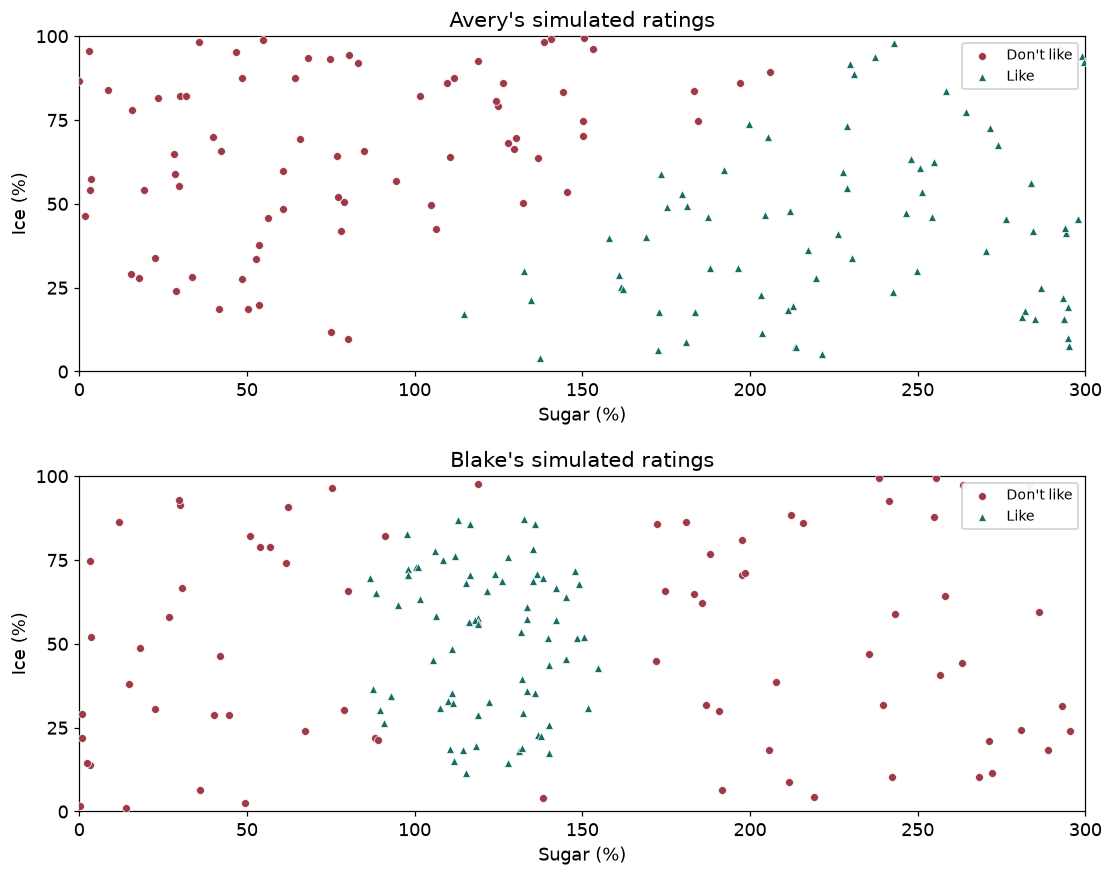

In [3]:
X_avery, y_avery = generate_boba_data(person="Avery", n_per_class=75, noise=0, seed=461)
X_blake, y_blake = generate_boba_data(person="Blake", n_per_class=75, noise=0, seed=462)
fig, axes = plt.subplots(2, 1, figsize=(10, 8), constrained_layout=True)
plot_boba_data(X_avery, y_avery, person="Avery", ax=axes[0], title="Avery's simulated ratings")
plot_boba_data(X_blake, y_blake, person="Blake", ax=axes[1], title="Blake's simulated ratings")
plt.show()

Avery's preference can be represented by a straight separator. Blake's enclosed Like region
requires a curved boundary.

The generator deliberately samples equal numbers from the clean Like and Don't like regions.
After synthetic label flips, the observed class counts need not be exactly equal.

## 1. Score, sigmoid, and probability

Write **sigm** for the sigmoid, **$a$** for the model's score,
**$b$** for the bias, and **$\mu_n$** for the predicted probability at recipe $x_n$:

$$a_n=w^T\phi(x_n)+b,\qquad
\mu_n=\operatorname{sigm}(a_n)=\frac{1}{1+e^{-a_n}}
=P(y_n=1\mid x_n,\theta).$$

$$p(y\mid x,\theta)=\operatorname{Ber}\!\left(y\mid\operatorname{sigm}(w^T\phi(x)+b)\right).$$

The model describes a **Bernoulli** response: Like or Don't like. The feature map $\phi$
lets us transform the inputs while retaining a weighted sum of features.

$$\hat y_n=\begin{cases}1,&\mu_n\geq0.5,\\0,&\mu_n<0.5,\end{cases}
\qquad \text{decision boundary: }\mu_n=0.5\ \Longleftrightarrow\ a_n=0.$$

For $0<\mu_n<1$, the inverse sigmoid is the **logit**, or log-odds:
$a_n=\log\frac{\mu_n}{1-\mu_n}$. A sigmoid probability always lies between zero and one.


Reference: [Class Conversion, Sigmoid, Notation, Intuition](https://firner.com/presentations/cs461/2026-Fall/cs461_04/#/31).

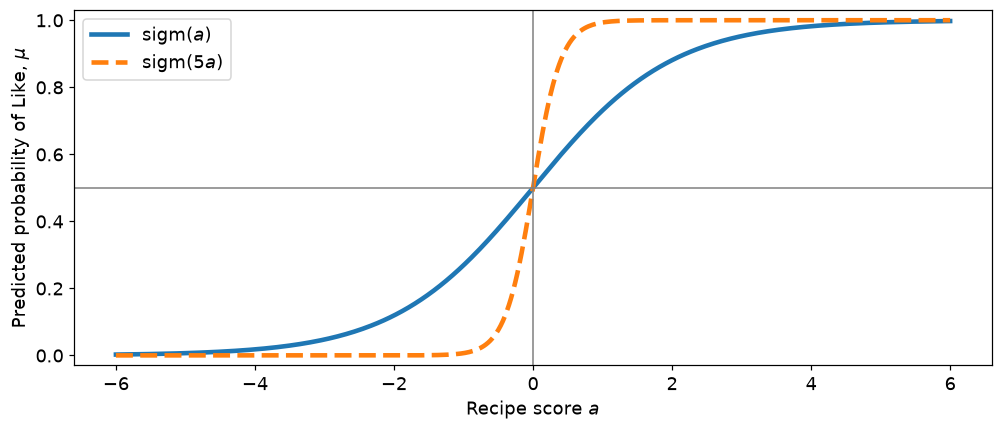

In [4]:
scores = np.linspace(-6, 6, 400)
fig, ax = plt.subplots(figsize=(9, 3.8), constrained_layout=True)
ax.plot(scores, sigmoid(scores), lw=3, label=r"$\mathrm{sigm}(a)$")
ax.plot(scores, sigmoid(5*scores), lw=3, ls="--", label=r"$\mathrm{sigm}(5a)$")
ax.axhline(0.5, color="gray", lw=1)
ax.axvline(0, color="gray", lw=1)
ax.set(xlabel=r"Recipe score $a$", ylabel=r"Predicted probability of Like, $\mu$", ylim=(-.03, 1.03))
ax.legend()
plt.show()

Both curves have the same zero-score boundary. Multiplying the score by five makes predictions
more confident away from that boundary. Thresholding both $0.51$ and $0.99$ to Like discards
this difference in confidence.

A sharper probability transition and a more complicated boundary are different things.

## 2. Change the features, change the possible boundaries

With $\phi(x)=[x_1,x_2]^T$, the boundary is the line

$$w_1x_1+w_2x_2+b=0.$$

Avery's illustrative preference depends on $x_1-1.5x_2-75$. A linear score can represent
this boundary. We now instantiate and train the model directly.


Reference: [Review and Decision Boundary](https://firner.com/presentations/cs461/2026-Fall/cs461_04/#/30).

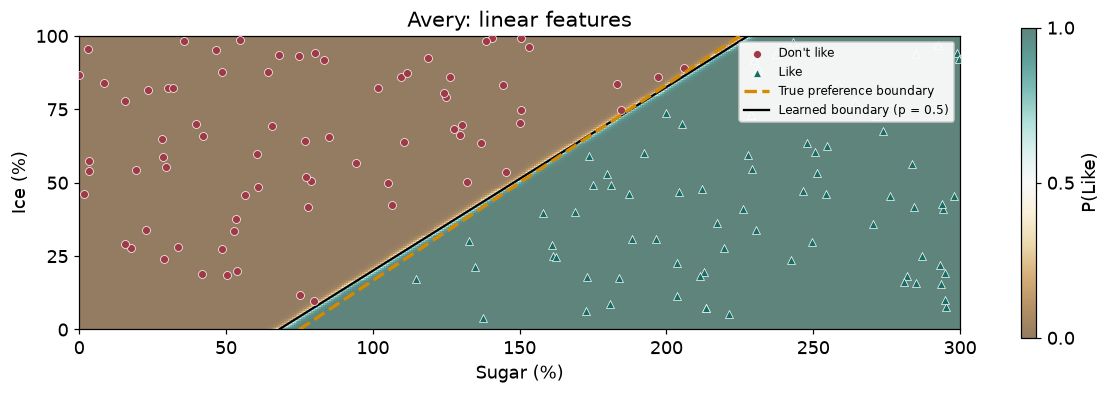

In [5]:
# Fixed teaching settings. They are not a recommended HW1 search result.
DEMO_EPOCHS = 4000
DEMO_LR = 0.05

avery_linear = LogisticRegressor(degree=1, cross_features=False, l1=0.0, l2=0.0,
    learning_rate=DEMO_LR, epochs=DEMO_EPOCHS, standardize=True)
avery_linear.fit(X_avery.T, y_avery)
fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)
plot_boba_model(avery_linear, X_avery, y_avery, person="Avery", ax=ax,
                title="Avery: linear features")
plt.show()

Blake's clean Like region is a circle around a moderate recipe:

$$(x_1-120)^2+(x_2-50)^2\leq40^2.$$

An illustrative score for that rule is

$$a=40^2-(x_1-120)^2-(x_2-50)^2
=-15300+240x_1+100x_2-x_1^2-x_2^2.$$

The feature map $\phi(x)=[x_1,x_2,x_1^2,x_2^2]^T$ makes that score possible.
It remains **linear in the weights**, even though the boundary is curved in input space.
These are generating-rule coefficients, not coefficients fitted from the sample.

Both plot axes use equal distance per percentage point, so the reference circle is round.
A fitted quadratic is not constrained to be an exact circle.


Reference: [Polynomials](https://firner.com/presentations/cs461/2026-Fall/cs461_04/#/52).

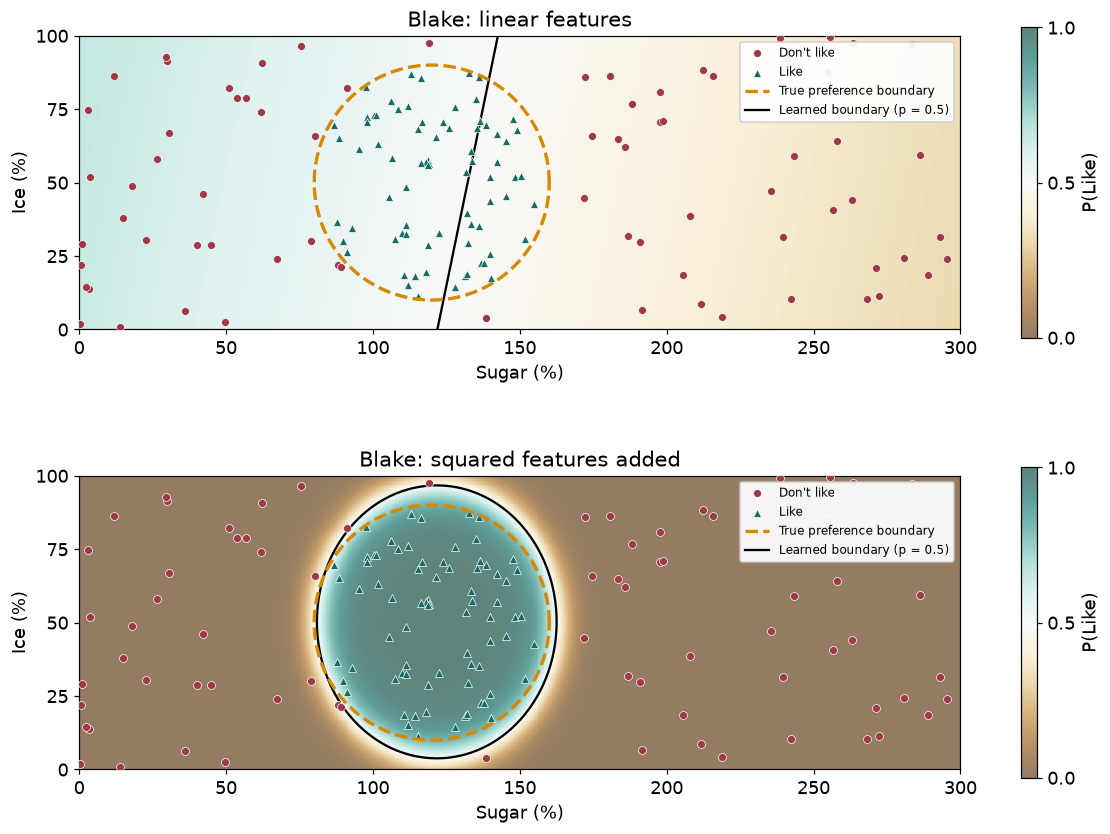

In [6]:
blake_linear = LogisticRegressor(degree=1, cross_features=False, l1=0.0, l2=0.0,
    learning_rate=DEMO_LR, epochs=DEMO_EPOCHS, standardize=True)
blake_linear.fit(X_blake.T, y_blake)
blake_quadratic = LogisticRegressor(degree=2, cross_features=False, l1=0.0, l2=0.0,
    learning_rate=DEMO_LR, epochs=DEMO_EPOCHS, standardize=True)
blake_quadratic.fit(X_blake.T, y_blake)
fig, axes = plt.subplots(2, 1, figsize=(10, 8), constrained_layout=True)
for ax, model, title in zip(axes, [blake_linear, blake_quadratic],
                           ["Blake: linear features", "Blake: squared features added"]):
    plot_boba_model(model, X_blake, y_blake, person="Blake", ax=ax, title=title)
plt.show()

### Chris: the effect of sugar depends on the ice setting

Chris likes **coordinated sugar and ice settings**: lower sugar with less ice and higher sugar
with more ice. Moderate matched recipes can also be liked. We simulate a narrow, tilted
preference region and a small amount of label noise.

Separate squared terms can bend a boundary, but an interaction term changes how the two
inputs act **together**. A quadratic score with a cross term can take the form

$$a=b+w_1x_1+w_2x_2+w_3x_1^2+w_4x_2^2+w_5x_1x_2.$$

The next comparison keeps the degree fixed and switches cross features off and on.
The interaction allows the fitted boundary to follow the tilted preference region.


Reference: [More Interesting Examples: polynomial and cross features](https://firner.com/presentations/cs461/2026-Fall/cs461_04/#/53).

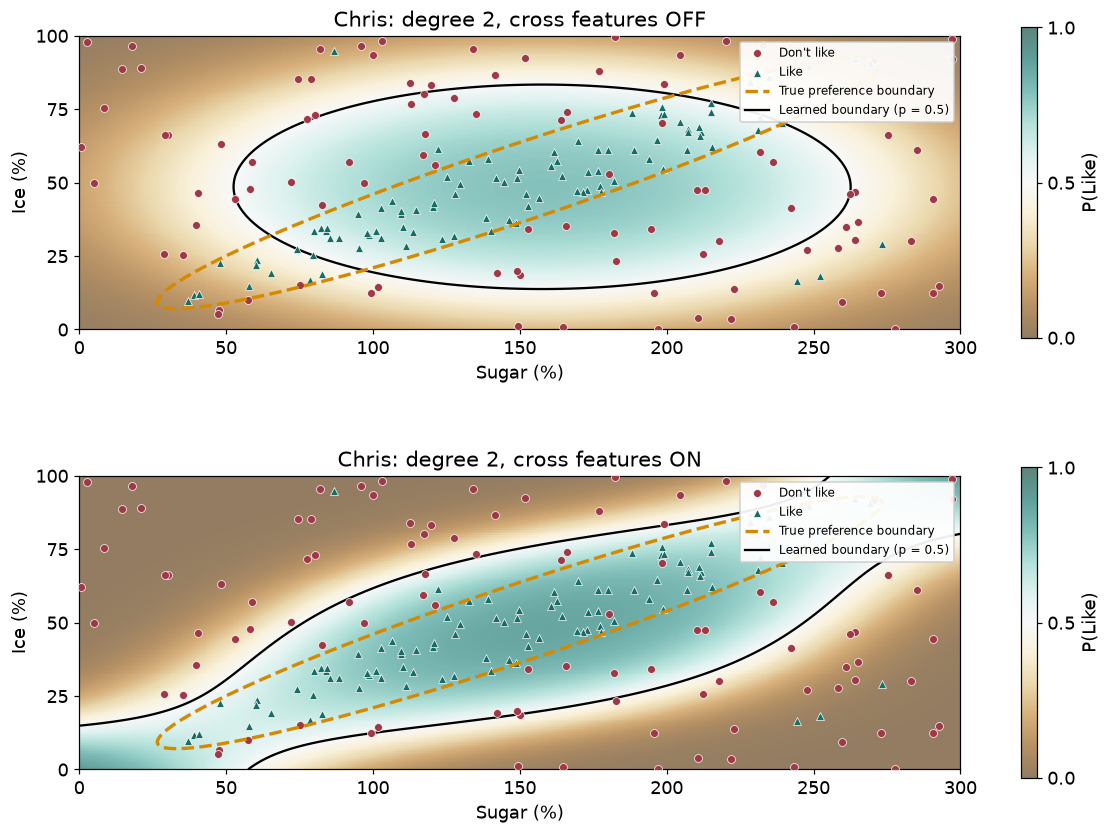

In [7]:
X_chris, y_chris = generate_boba_data(person="Chris", n_per_class=100, noise=0.04, seed=463)
chris_separate = LogisticRegressor(degree=2, cross_features=False, l1=0.0, l2=0.0,
    learning_rate=DEMO_LR, epochs=DEMO_EPOCHS, standardize=True)
chris_separate.fit(X_chris.T, y_chris)
chris_interaction = LogisticRegressor(degree=2, cross_features=True, l1=0.0, l2=0.0,
    learning_rate=DEMO_LR, epochs=DEMO_EPOCHS, standardize=True)
chris_interaction.fit(X_chris.T, y_chris)
fig, axes = plt.subplots(2, 1, figsize=(10, 8), constrained_layout=True)
for ax, model, title in zip(axes, [chris_separate, chris_interaction],
    ["Chris: degree 2, cross features OFF", "Chris: degree 2, cross features ON"]):
    plot_boba_model(model, X_chris, y_chris, person="Chris", ax=ax, title=title)
plt.show()

### How the feature expansion works

`use_cross` in the assignment corresponds to `cross_features` in `LogisticRegressor`.
This class adds the product first, then takes powers of every resulting feature:

| Configuration | Expanded features |
|---|---|
| degree 1, cross off | $[u_1,u_2]$ |
| degree 1, cross on | $[u_1,u_2,u_1u_2]$ |
| degree 2, cross off | $[u_1,u_2,u_1^2,u_2^2]$ |
| degree 2, cross on | $[u_1,u_2,u_1u_2,u_1^2,u_2^2,(u_1u_2)^2]$ |

This is **not** a complete polynomial expansion by total degree. The last row includes a
fourth-total-degree term. Increasing degree and enabling cross features are different choices.
The class keeps bias $b$ separate, so its feature list does not include a constant column.

For these percentage-valued boba examples, `standardize=True` defines
$u_j=(x_j-\bar x_j)/(s_j+\epsilon)$ **before** feature expansion. The mean and scale are learned
only from the current training inputs. With standardization off, $u_j=x_j$.

### One recipe, three preference predictions

For the same recipe—$120\%$ sugar and $50\%$ ice—the three models can predict different
responses because each was trained on a different person's preferences.

In [8]:
SUGAR = 120  # 0 to 300
ICE = 50     # 0 to 100
assert 0 <= SUGAR <= 300 and 0 <= ICE <= 100
recipe = np.array([[SUGAR, ICE]])
order_predictions = []
for person, model in [("Avery", avery_linear), ("Blake", blake_quadratic), ("Chris", chris_interaction)]:
    probability = model.decision_function(recipe)[0]
    order_predictions.append({"Student": person, "Sugar (%)": SUGAR, "Ice (%)": ICE,
        "Predicted P(Like)": round(probability, 3),
        "Predicted class": "Like" if probability >= 0.5 else "Don't like"})
display(pd.DataFrame(order_predictions))

,Student,Sugar (%),Ice (%),Predicted P(Like),Predicted class
0,Avery,120,50,0.000,Don't like
1,Blake,120,50,0.998,Like
2,Chris,120,50,0.815,Like


## 3. From likelihood to binary cross-entropy

For independent observations, the conditional likelihood is the product of the
probabilities of the observed labels:

$$CL(w,b)=\prod_{n=1}^{N}\mu_n^{y_n}(1-\mu_n)^{1-y_n}.$$

Taking the negative log gives the **negative log-likelihood (NLL)**:

$$NLL(w,b)=-\sum_{n=1}^{N}\left[y_n\log\mu_n+(1-y_n)\log(1-\mu_n)\right].$$

Each summand is a binary cross-entropy loss. Our code reports the average:

$$\operatorname{BCE}=\frac{NLL}{N},\qquad
\ell(y,\mu)=-\left[y\log\mu+(1-y)\log(1-\mu)\right].$$

Lower BCE is better. Averaging makes the score comparable across sets of different sizes.
Both class terms are necessary; use predicted probabilities, not hard labels.


Reference: [Optimization and Notes](https://firner.com/presentations/cs461/2026-Fall/cs461_04/#/36).

In [9]:
ratings = pd.DataFrame({"Observed preference": ["Like", "Like", "Don't like", "Don't like"],
    "Label": [1, 1, 0, 0], "Predicted P(Like)": [0.60, 0.99, 0.60, 0.99]})
ratings["Predicted class"] = np.where(ratings["Predicted P(Like)"] >= .5, "Like", "Don't like")
ratings["BCE for this recipe"] = [cross_entropy_loss(np.array([p]), np.array([label]))
    for p, label in zip(ratings["Predicted P(Like)"], ratings.Label)]
display(ratings.drop(columns="Label").round(4))

,Observed preference,Predicted P(Like),Predicted class,BCE for this recipe
0,Like,0.60,Like,0.5108
1,Like,0.99,Like,0.0101
2,Don't like,0.60,Like,0.9163
3,Don't like,0.99,Like,4.6052


The last two predictions are both incorrect, so their accuracy is the same. BCE penalizes
the confidently wrong probability of $0.99$ more heavily than the probability of $0.60$.

$$\operatorname{accuracy}=\frac{1}{N}\sum_{n=1}^{N}\mathbf{1}[\hat y_n=y_n].$$

Accuracy evaluates hard decisions; BCE evaluates probabilities. Higher accuracy is better,
while lower BCE is better. The model comparison below uses mean validation accuracy for
selection and also reports BCE to describe the quality of the predicted probabilities.


[HW1: Background](https://firner.com/presentations/cs461/2026-Fall/hw1.html).

### Training with gradients

For the **mean** BCE, the gradients are

$$\nabla_w\operatorname{BCE}=\frac{1}{N}\sum_{n=1}^{N}(\mu_n-y_n)\phi(x_n),
\qquad \frac{\partial\operatorname{BCE}}{\partial b}
=\frac{1}{N}\sum_{n=1}^{N}(\mu_n-y_n).$$

An ordinary gradient step is $w_{k+1}=w_k-\eta_k\nabla_w\operatorname{BCE}$.
For the summed NLL, omit the factor $1/N$. Keep that normalization consistent.
The HW1 class uses an adaptive RMSProp weight step and an ordinary bias step.

`learning_rate` controls the step size; `epochs` controls the training budget. A more
expressive feature map cannot compensate for a model that has not trained adequately.
The comparisons below hold these training settings fixed while changing the feature map
or regularization strength.


Reference: [Gradient Solution, Simple!, Interpretation](https://firner.com/presentations/cs461/2026-Fall/cs461_04/#/38).

## 4. Noise, Ridge, and Lasso

A model can learn both a relationship and noise in the observations. A more complicated
model can fit training observations better while predicting new observations worse.

Ridge regression uses squared-error loss plus a penalty:

$$Error=\frac{1}{N}\sum_{n=1}^{N}\left(y_n-(w_0+w^Tx_n)\right)^2
+\lambda\lVert w\rVert_2^2.$$

That equation is for **linear regression**. For logistic regression, the data-fitting loss
is NLL or BCE. The penalty ideas remain useful:

$$\lVert w\rVert_2^2=\sum_j w_j^2,\qquad\lVert w\rVert_1=\sum_j|w_j|.$$

| Choice | Name | Main intuition |
|---|---|---|
| No penalty | Unregularized | Let the training data determine the coefficients |
| L2 | Ridge / weight decay | Discourage large coefficient magnitudes |
| L1 | Lasso | Encourage sparse representations; some components can become unnecessary |

In the MAP interpretation, Gaussian and Laplace weight priors correspond to the familiar
L2 and L1 penalty forms, respectively. The bias is not penalized in the provided model.
Both strengths can be set independently; zero disables the corresponding contribution.

**Implementation detail:** the released HW1 code adds its L1/L2 shrinkage after the RMSProp
normalization. Use that update when interpreting its `l1` and `l2` values; it is not the same
as putting a penalty gradient inside RMSProp. Its finite sign-based L1 steps do not guarantee
exactly zero coefficients. A small or rounded coefficient is not automatically an exact zero.


Reference: [Ridge Regression](https://firner.com/presentations/cs461/2026-Fall/cs461_04/#/12). Reference: [Lasso Regularization, Lasso Vs Ridge, Meaning](https://firner.com/presentations/cs461/2026-Fall/cs461_04/#/21).

### A separate test set for final evaluation

Start a fresh experiment with **500 noisy Blake ratings**, separate from the warm-up examples.
Reserve $20\%$ for final testing and use $80\%$ for development:

$$500\text{ ratings}\longrightarrow
\underbrace{400\text{ development ratings}}_{80\%}
+\underbrace{100\text{ test ratings}}_{20\%}.$$

The initial split is stratified. Only development data may be used for exploration, model
comparison, cross-validation, and refitting. The test set stays untouched until final evaluation.

In [10]:
PERSON = "Blake"
X_all, y_all = generate_boba_data(person=PERSON, n_per_class=250, noise=.12, seed=1462)
dev_indices, test_indices = train_test_split(np.arange(len(y_all)), test_size=.20,
    stratify=y_all, random_state=461)
X_dev, y_dev = X_all[dev_indices], y_all[dev_indices]
X_test, y_test = X_all[test_indices], y_all[test_indices]
assert set(dev_indices).isdisjoint(test_indices)
print(f"Development: {len(y_dev)} recipes; reserved test: {len(y_test)} recipes.")
display(pd.Series(y_dev).map({0:"Don't like", 1:"Like"}).value_counts().rename("Development class counts"))

Development: 400 recipes; reserved test: 100 recipes.


Don't like    202
Like          198
Name: Development class counts, dtype: int64

The clean generating label is independently flipped with probability $0.12$.
This is an illustrative noise mechanism, not a measured model of real students.
The clean/noisy comparison below uses **the same development recipes**.

The following plots show how L1 and L2 change the fitted coefficients and probability
surface. A smoother-looking surface alone does not establish better predictions on new data.

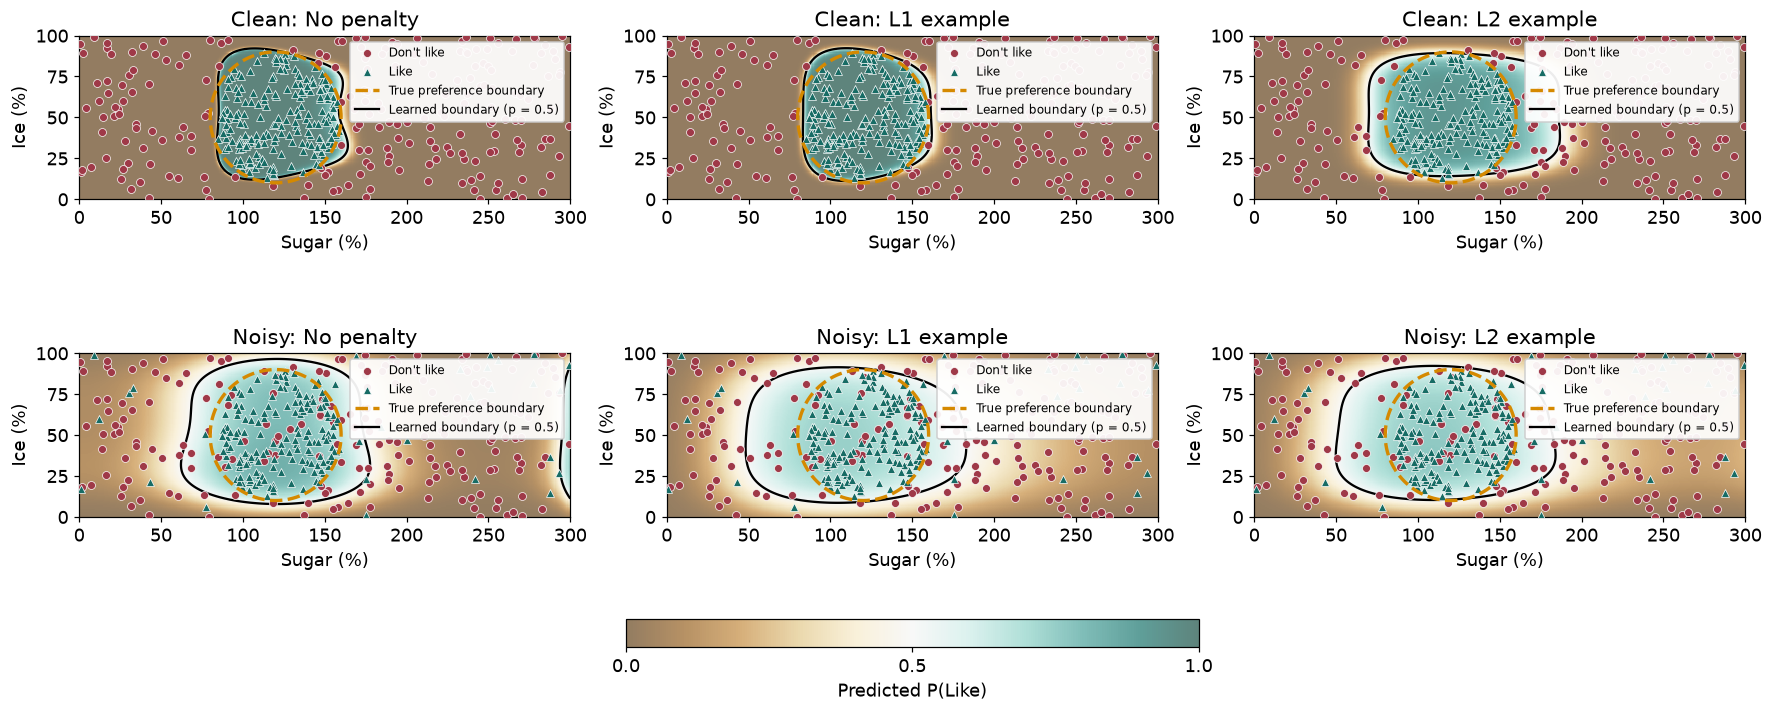

In [11]:
y_dev_clean = (true_boba_score(X_dev, person=PERSON) >= 0).astype(int)
# Three fixed classroom comparisons, not a hyperparameter search.
penalty_examples = [("No penalty", 0.0, 0.0), ("L1 example", 0.5, 0.0), ("L2 example", 0.0, 0.5)]
fig, axes = plt.subplots(2, 3, figsize=(16, 7), constrained_layout=True)
noisy_penalty_models = {}
for row, (labels, label_title) in enumerate([(y_dev_clean, "Clean"), (y_dev, "Noisy")]):
    for col, (name, l1_strength, l2_strength) in enumerate(penalty_examples):
        model = LogisticRegressor(degree=4, cross_features=False, l1=l1_strength, l2=l2_strength,
            learning_rate=DEMO_LR, epochs=DEMO_EPOCHS, standardize=True)
        model.fit(X_dev.T, labels)
        plot_boba_model(model, X_dev, labels, person=PERSON, ax=axes[row, col], colorbar=False,
            title=f"{label_title}: {name}")
        if row == 1:
            noisy_penalty_models[name] = model
fig.colorbar(axes[0,0].collections[0], ax=axes.ravel().tolist(), orientation="horizontal",
    shrink=.6, fraction=.05, pad=.08, label="Predicted P(Like)", ticks=[0,.5,1])
plt.show()

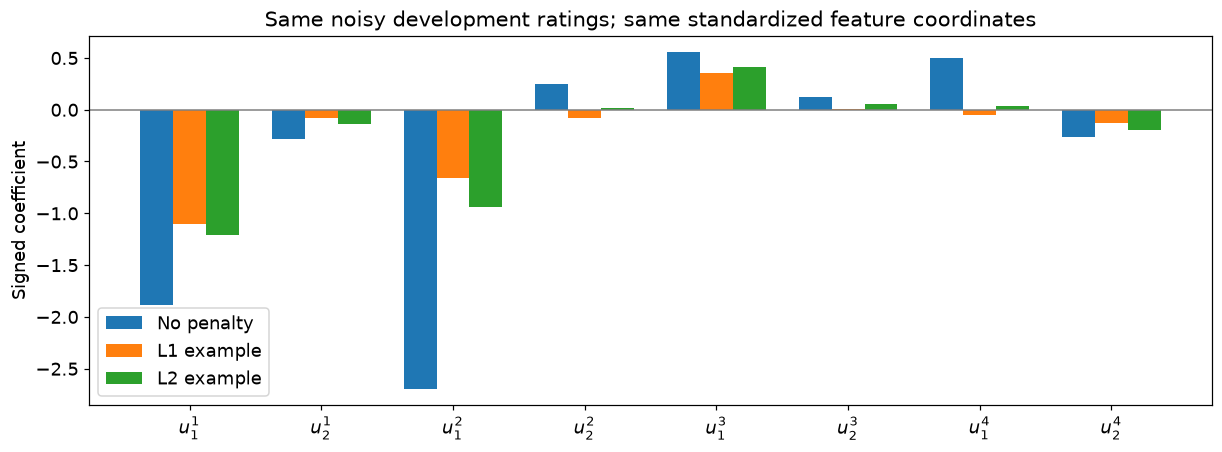

In [12]:
feature_names = [rf"$u_{j}^{d}$" for d in range(1,5) for j in [1,2]]
positions = np.arange(len(feature_names))
fig, ax = plt.subplots(figsize=(11, 4), constrained_layout=True)
for offset, (name, model) in zip([-.25, 0, .25], noisy_penalty_models.items()):
    ax.bar(positions+offset, model.weights_, width=.25, label=name)
ax.axhline(0, color="gray", lw=1)
ax.set(xticks=positions, xticklabels=feature_names, ylabel="Signed coefficient",
       title="Same noisy development ratings; same standardized feature coordinates")
ax.legend()
plt.show()

Changing the penalty changes the fitted coefficients without adding or removing available
features. L1 and L2 apply different forms of shrinkage, so equal numerical strengths do not
produce equivalent effects. The coefficient plot shows the result in the same feature coordinates.

Neither zero regularization nor positive regularization always wins. These are training-data
pictures, so they motivate comparisons; they do not select the best model. Regularization is
not a substitute for more data. For separable unregularized logistic regression, coefficient
magnitudes need not converge to a finite optimum.


Reference: [Proper Usage](https://firner.com/presentations/cs461/2026-Fall/cs461_04/#/17).

## 5. Cross-validation and model comparison

Parameters $w,b$ are fitted from training data. Hyperparameters choose the feature map and
penalty strengths. Only the **400 development ratings** are split into five folds:

- Each fit uses 320 training recipes and 80 validation recipes.
- Each development recipe is used for validation once.
- The original 100 test recipes participate in no CV fit or score.
- Every fold uses a fresh model and preprocessing statistics fitted on its training rows.

For a configuration $h$, summarize the validation metric with

$$CV_{acc}(h)=\frac{1}{5}\sum_{k=1}^{5}acc_{V_k}(h),\qquad
CV_{BCE}(h)=\frac{1}{5}\sum_{k=1}^{5}BCE_{V_k}(h).$$

All configurations use the same saved folds. Validation scores exclude the
regularization penalty. Preprocessing must be learned on that fold's training portion only.


[HW1: Background](https://firner.com/presentations/cs461/2026-Fall/hw1.html); [scikit-learn: cross-validation](https://scikit-learn.org/stable/modules/cross_validation.html).

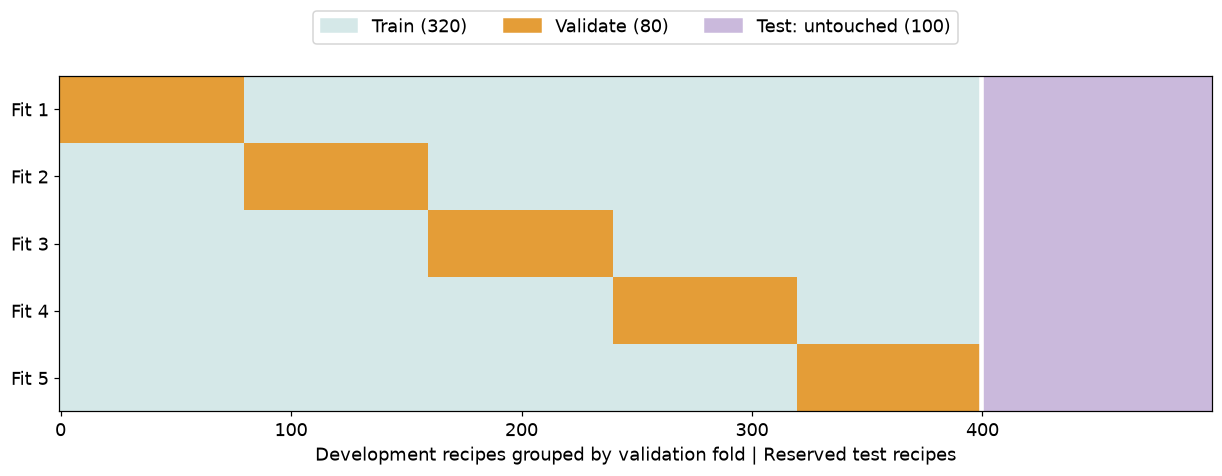

In [13]:
N_FOLDS = 5
splits = list(StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=461).split(X_dev, y_dev))
# Group development columns by their validation fold for this picture only.
display_order = np.concatenate([val_idx for _, val_idx in splits])
development_membership = np.zeros((N_FOLDS, len(X_dev)), dtype=int)
for row, (_, val_idx) in enumerate(splits):
    development_membership[row, val_idx] = 1
membership = np.full((N_FOLDS, len(X_all)), 2, dtype=int)
membership[:, :len(X_dev)] = development_membership[:, display_order]
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
fig, ax = plt.subplots(figsize=(11,4.2), constrained_layout=True)
ax.imshow(membership, aspect="auto", cmap=ListedColormap(["#d5e8e8", "#e49d37", "#cab9dc"]),
    interpolation="nearest", vmin=0, vmax=2)
ax.axvline(len(X_dev)-.5, color="white", lw=3)
ax.set(yticks=np.arange(N_FOLDS), yticklabels=[f"Fit {k+1}" for k in range(N_FOLDS)],
    xlabel="Development recipes grouped by validation fold | Reserved test recipes")
ax.legend(handles=[Patch(color="#d5e8e8",label="Train (320)"),
    Patch(color="#e49d37",label="Validate (80)"), Patch(color="#cab9dc",label="Test: untouched (100)")],
    loc="upper center", bbox_to_anchor=(.5,1.22), ncol=3)
plt.show()

### Evaluating one configuration

In Fit 1, only its 320 training recipes determine the standardization mean and scale.
Fit 2 starts with a fresh model: reusing Fit 1's weights would carry information from
recipes that Fit 2 is supposed to hold out.

The next cell shows the five validation scores for one fixed configuration. Their average
summarizes this configuration's performance across the five held-out folds.

In [14]:
DEMO_CANDIDATE = {"degree": 2, "cross_features": False, "l1": 0.0, "l2": 0.1}
fold_rows = []
for fold, (train_idx, val_idx) in enumerate(splits, start=1):
    model = LogisticRegressor(**DEMO_CANDIDATE, learning_rate=DEMO_LR,
        epochs=DEMO_EPOCHS, standardize=True)
    model.fit(X_dev[train_idx].T, y_dev[train_idx])
    train_p = model.decision_function(X_dev[train_idx])
    val_p = model.decision_function(X_dev[val_idx])
    fold_rows.append({"Fold": fold, "Train rows": len(train_idx), "Validation rows": len(val_idx),
        "Train BCE": cross_entropy_loss(train_p, y_dev[train_idx]),
        "Validation BCE": cross_entropy_loss(val_p, y_dev[val_idx]),
        "Validation accuracy": np.mean((val_p >= .5) == y_dev[val_idx])})
fold_scores = pd.DataFrame(fold_rows)
display(fold_scores.round(4))
display(fold_scores[["Validation accuracy", "Validation BCE"]].agg(["mean", "std"]).round(4))

,Fold,Train rows,Validation rows,Train BCE,Validation BCE,Validation accuracy
0,1,320,80,0.5773,0.5317,0.8000
1,2,320,80,0.5140,0.8514,0.7125
2,3,320,80,0.5829,0.5215,0.7875
3,4,320,80,0.5738,0.5463,0.8250
4,5,320,80,0.5775,0.5345,0.7750


,Validation accuracy,Validation BCE
mean,0.780,0.5971
std,0.042,0.1425


### Comparing mean validation accuracy

The demonstration compares six fixed configurations on the noisy Blake ratings:

- Polynomial degree $d\in\{1,2,4\}$.
- L2 strength $\lambda_2\in\{0,0.1\}$.
- Cross features remain off and L1 remains zero.

All six use the same five folds, learning rate, epoch budget, and training-only
standardization. Changing the degree changes the available features; changing L2 changes
the shrinkage applied during fitting. Holding the other choices fixed makes their effects
easier to compare.

Each bar shows the **mean validation accuracy over five folds**. The error bar is
one fold standard deviation, not a confidence interval. These are illustrative boba
configurations, not recommendations for another dataset.

[Reference: cross-validation and model selection](https://scikit-learn.org/stable/modules/cross_validation.html).

In [15]:
# A small, fixed classroom comparison on the synthetic development data.
DEMO_DEGREES = [1, 2, 4]
DEMO_L2_STRENGTHS = [0.0, 0.1]
comparison_rows = []
for degree in DEMO_DEGREES:
    for l2_strength in DEMO_L2_STRENGTHS:
        settings = {"degree": degree, "cross_features": False, "l1": 0.0, "l2": l2_strength}
        if settings == DEMO_CANDIDATE:
            # Reuse the five scores already computed for this exact configuration.
            for row in fold_rows:
                comparison_rows.append({**settings, "Fold": row["Fold"],
                    "Validation accuracy": row["Validation accuracy"],
                    "Validation BCE": row["Validation BCE"]})
            continue
        for fold, (train_idx, val_idx) in enumerate(splits, start=1):
            model = LogisticRegressor(**settings, learning_rate=DEMO_LR,
                epochs=DEMO_EPOCHS, standardize=True)
            model.fit(X_dev[train_idx].T, y_dev[train_idx])
            val_p = model.decision_function(X_dev[val_idx])
            comparison_rows.append({**settings, "Fold": fold,
                "Validation accuracy": np.mean((val_p >= .5) == y_dev[val_idx]),
                "Validation BCE": cross_entropy_loss(val_p, y_dev[val_idx])})

comparison_scores = pd.DataFrame(comparison_rows)
comparison_summary = comparison_scores.groupby(["degree", "l2"], as_index=False).agg(
    mean_validation_accuracy=("Validation accuracy", "mean"),
    std_validation_accuracy=("Validation accuracy", "std"),
    mean_validation_bce=("Validation BCE", "mean"))
display(comparison_summary.rename(columns={"degree": "Degree", "l2": "L2",
    "mean_validation_accuracy": "Mean validation accuracy",
    "std_validation_accuracy": "Fold accuracy SD",
    "mean_validation_bce": "Mean validation BCE"}).round(4))

# Selection uses unrounded validation means, never the reserved test results.
# An exact tie keeps the first row (lower degree, then lower L2 in this table).
best_row = comparison_summary.loc[comparison_summary.mean_validation_accuracy.idxmax()]
selected_config = {"degree": int(best_row.degree), "cross_features": False,
                   "l1": 0.0, "l2": float(best_row.l2)}


,Degree,L2,Mean validation accuracy,Fold accuracy SD,Mean validation BCE
0,1,0.0,0.6300,0.0314,0.6781
1,1,0.1,0.6300,0.0314,0.6780
2,2,0.0,0.7800,0.0420,0.5975
3,2,0.1,0.7800,0.0420,0.5971
4,4,0.0,0.8075,0.0647,0.5061
5,4,0.1,0.8125,0.0586,0.5053


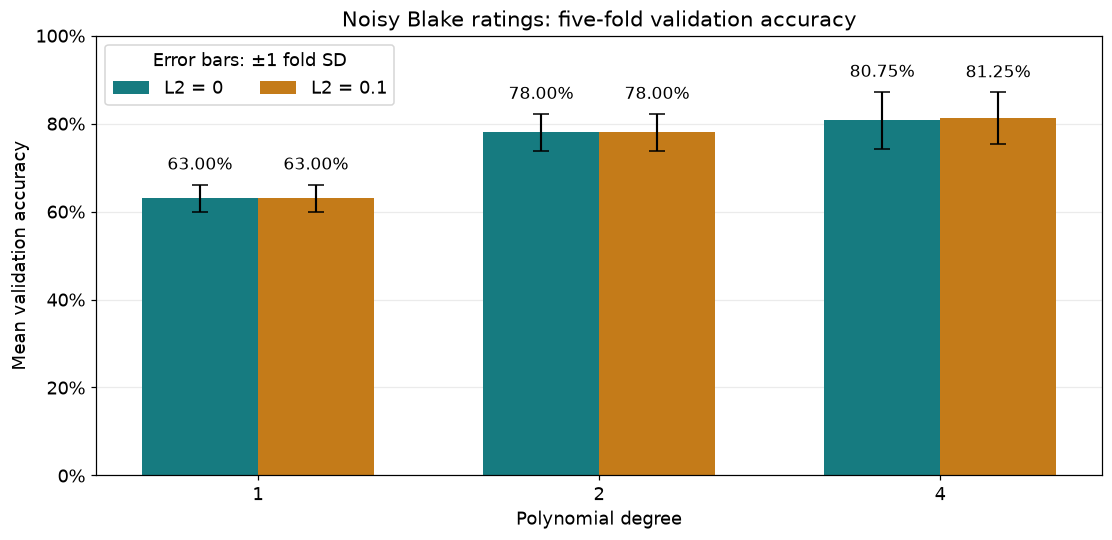

Selected among these six configurations: degree=4, L2=0.1
Highest mean validation accuracy: 81.2%


In [16]:
from matplotlib.ticker import PercentFormatter

fig, ax = plt.subplots(figsize=(10, 4.8), constrained_layout=True)
positions = np.arange(len(DEMO_DEGREES))
width = .34
for l2_strength, offset, color in [(0.0, -width/2, "#167b80"), (0.1, width/2, "#c47b19")]:
    group = comparison_summary[comparison_summary.l2 == l2_strength].sort_values("degree")
    centers = positions + offset
    ax.bar(centers, group.mean_validation_accuracy, width=width,
        yerr=group.std_validation_accuracy, color=color, capsize=5,
        error_kw={"elinewidth": 1.4}, label=f"L2 = {l2_strength:g}")
    for x, mean, sd in zip(centers, group.mean_validation_accuracy, group.std_validation_accuracy):
        ax.text(x, mean+sd+.025, f"{mean:.2%}", ha="center", va="bottom", fontsize=11)
ax.set(xticks=positions, xticklabels=DEMO_DEGREES, xlabel="Polynomial degree",
       ylabel="Mean validation accuracy", ylim=(0, 1),
       title="Noisy Blake ratings: five-fold validation accuracy")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_axisbelow(True)
ax.grid(axis="y", alpha=.25)
ax.legend(title="Error bars: ±1 fold SD", loc="upper left", ncol=2)
plt.show()
print(f"Selected among these six configurations: degree={selected_config['degree']}, "
      f"L2={selected_config['l2']:g}")
print(f"Highest mean validation accuracy: {best_row.mean_validation_accuracy:.1%}")


Taller bars indicate better average classification accuracy on held-out development folds.
Comparing bars of the same color shows the effect of degree at a fixed L2 strength; comparing
the two bars within a degree shows the effect of L2 at a fixed feature map. Side-by-side bars
keep equal or nearly equal scores visible. A tie in accuracy can still accompany a difference
in BCE because the metrics measure different aspects of the predictions.

The selected configuration has the largest **unrounded mean validation accuracy among these
six candidates**. It need not be best among all possible configurations or on another dataset.
Overlapping error bars do not establish a statistically meaningful difference. The selected
CV score has already influenced model choice, so a separate test is still needed for final
evaluation.

## 6. Refit, then evaluate the original held-out test set

The configuration selected by mean validation accuracy is now fitted from scratch on
**all 400 development recipes**. Preprocessing is fitted again on these 400 recipes.
The final model is then evaluated on the **same 100 test recipes** reserved at the start.

The test recipes did not contribute to the comparison plot or the choice of configuration.

CV-selected classroom configuration: {'degree': 4, 'cross_features': False, 'l1': 0.0, 'l2': 0.1}
Refit: 400 development recipes | Test: 100 reserved recipes
Held-out accuracy: 83.0% | Held-out mean BCE: 0.4255


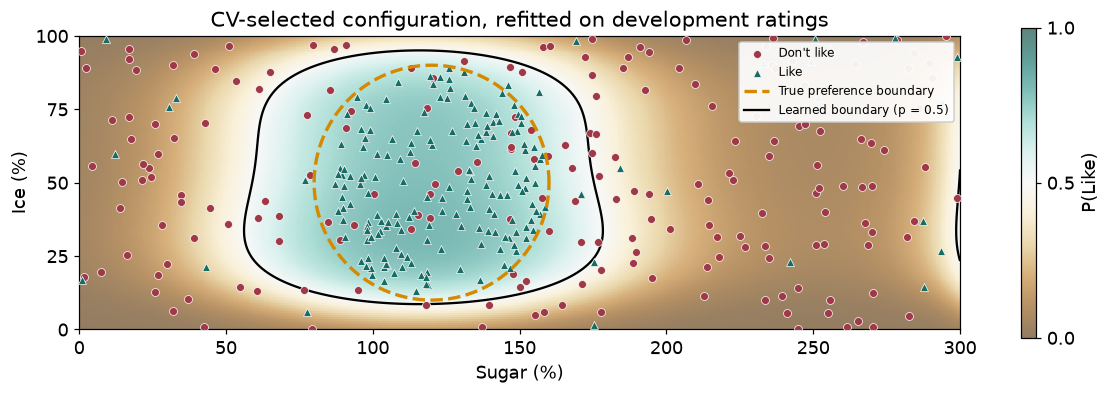

In [17]:
final_model = LogisticRegressor(**selected_config, learning_rate=DEMO_LR,
    epochs=DEMO_EPOCHS, standardize=True)
final_model.fit(X_dev.T, y_dev)

# First evaluation on the original reserved test set.
test_p = final_model.decision_function(X_test)
test_bce = cross_entropy_loss(test_p, y_test)
test_accuracy = np.mean((test_p >= .5) == y_test)
print(f"CV-selected classroom configuration: {selected_config}")
print(f"Refit: {len(y_dev)} development recipes | Test: {len(y_test)} reserved recipes")
print(f"Held-out accuracy: {test_accuracy:.1%} | Held-out mean BCE: {test_bce:.4f}")
fig, ax = plt.subplots(figsize=(10,4), constrained_layout=True)
plot_boba_model(final_model, X_dev, y_dev, person=PERSON, ax=ax,
    title="CV-selected configuration, refitted on development ratings")
plt.show()

Using the test results to revise the candidate choices would make that set part of model
development. Configuration choices therefore use development-set validation only.

Class imbalance affects model evaluation. Stratification preserves proportions;
it does not rebalance classes. A majority-class prediction can achieve high accuracy
without learning a useful boundary. Class weighting can adjust each class's contribution
to training; this demonstration instead keeps the training procedure fixed.


Reference: [Unbalanced Data and Balancing Data](https://firner.com/presentations/cs461/2026-Fall/cs461_04/#/47).

## 7. From Regression to Neural Network: [Tensorflow Playground](https://playground.tensorflow.org/#activation=sigmoid&batchSize=10&dataset=xor&regDataset=reg-plane&learningRate=0.1&regularizationRate=0&noise=25&networkShape=1&seed=0.87688&showTestData=false&discretize=false&percTrainData=50&x=true&y=true&xTimesY=true&xSquared=true&ySquared=true&cosX=false&sinX=false&cosY=false&sinY=false&collectStats=false&problem=classification&initZero=false&hideText=false)

## Sources and running this notebook elsewhere

- [Lecture 4: Logistic Regression](https://firner.com/presentations/cs461/2026-Fall/cs461_04/#/):
  notation, sigmoid/Bernoulli model, NLL, gradients, polynomial and interaction features,
  Ridge/Lasso, vector orientations, and class imbalance. Direct slide links appear above.
- [HW1](https://firner.com/presentations/cs461/2026-Fall/hw1.html) and its linked starter code:
  feature convention and released estimator update.
- Murphy, [*Probabilistic Machine Learning: An Introduction*](https://probml.github.io/pml-book/book1.html),
  §§10.2–10.2.3, §§10.2.7–10.2.8, §§4.5.4–4.5.5: supporting explanations of logistic regression,
  regularization, preprocessing, and model selection.

This single notebook contains the model, simulated data, plots, and saved outputs. No local
helper module or CSV is required. A CPU runtime is sufficient; run cells from top to bottom.
The setup cell installs missing dependencies if needed.

- [Colab](https://research.google.com/colaboratory/faq.html): File → Upload notebook, then run all cells.
- [Deepnote](https://deepnote.com/docs/importing-and-exporting-jupyter-notebooks): import the `.ipynb` and run in order.